### Fashion MNIST to hdfs

Need to load Fashion MNIST onto hdfs, but can only access by loading through libraries. 
Going to import through library then download the dataset and load to hdfs,bto then load back into the notebook.

This is obviously not a sensible practice, I am just doing this to show my ability to use hdfs and hadoop to store and process data 

In [1]:
import torch
import torch.utils.data
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd

In [2]:
#import full dataset

full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

In [3]:
#using too much RAM and kernel is dying so using a subset of the data

sample_size = 1000
subset = torch.utils.data.Subset(full_dataset, range(sample_size))

In [4]:
# Converting dataset to DataFrame
images = []
labels = []

for img, label in subset:
    flat_img = img.view(-1).tolist()  
    images.append(flat_img)
    labels.append(label)

In [5]:
# Creating DataFrame with pixel columns
df = pd.DataFrame(images, columns=[f'pixel_{i}' for i in range(784)])

In [6]:
# Add label column 
df['label'] = labels

In [7]:
# save to CSV
df.to_csv('Fashion_MNIST_sample.csv', index=False)

print("Saved 'Fashion_MNIST_sample.csv'. Ready to upload to hdfs.")

Saved 'Fashion_MNIST_sample.csv'. Ready to upload to hdfs.


/home/hduser/Pictures/Screenshots/Screenshot from 2025-03-29 21-53-39.png
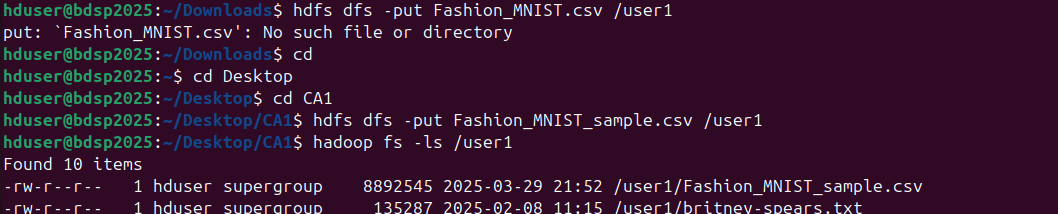

In [8]:
#import from hdfs with SparkSession
spark = SparkSession.builder.appName("FashionMNIST_Sample").getOrCreate()

25/03/29 21:57:09 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [10]:
#reading in the sample dataset
df = spark.read.csv('/user1/Fashion_MNIST_sample.csv', header=True, inferSchema=True)
df.printSchema()
df.show(5)

root
 |-- pixel_0: double (nullable = true)
 |-- pixel_1: double (nullable = true)
 |-- pixel_2: double (nullable = true)
 |-- pixel_3: double (nullable = true)
 |-- pixel_4: double (nullable = true)
 |-- pixel_5: double (nullable = true)
 |-- pixel_6: double (nullable = true)
 |-- pixel_7: double (nullable = true)
 |-- pixel_8: double (nullable = true)
 |-- pixel_9: double (nullable = true)
 |-- pixel_10: double (nullable = true)
 |-- pixel_11: double (nullable = true)
 |-- pixel_12: double (nullable = true)
 |-- pixel_13: double (nullable = true)
 |-- pixel_14: double (nullable = true)
 |-- pixel_15: double (nullable = true)
 |-- pixel_16: double (nullable = true)
 |-- pixel_17: double (nullable = true)
 |-- pixel_18: double (nullable = true)
 |-- pixel_19: double (nullable = true)
 |-- pixel_20: double (nullable = true)
 |-- pixel_21: double (nullable = true)
 |-- pixel_22: double (nullable = true)
 |-- pixel_23: double (nullable = true)
 |-- pixel_24: double (nullable = true)
 |-- 

25/03/29 22:02:49 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------+-------+-------+-------+--------------------+-------+-------+-------------------+-------------------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------------+--------------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------------------+--------+--------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------------------+------------------+------------------+------------------+------------------+------------------+-------------

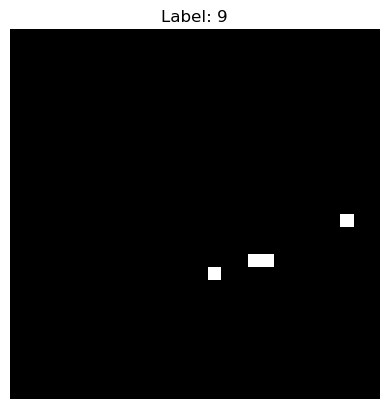

In [11]:
# getting one sample image
sample = df.limit(1).toPandas().iloc[0]

# Extract and reshape pixels
pixels = np.array([sample[f'pixel_{i}'] for i in range(784)], dtype=np.uint8).reshape(28, 28)

# Get label... making sure it's not saved as a string
label = int(sample['label'])

# Plot the image
plt.imshow(pixels, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [17]:
#add in label names using class names for Fashion MNIST

label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Convert label to int and get class name
label_index = int(sample['label'])
label_name = label_names[label_index]

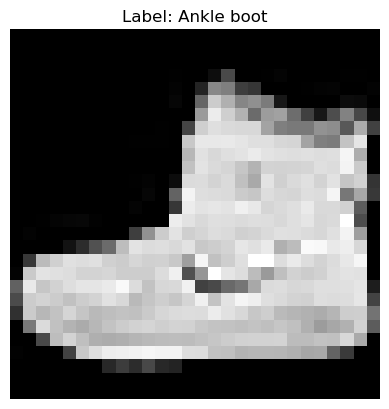

In [18]:
#need to unnormalize the pixels (unscale)
# Manually scale values up
pixels = np.array([float(sample[f'pixel_{i}']) * 255 for i in range(784)], dtype=np.uint8).reshape(28, 28)


plt.imshow(pixels, cmap='gray')
plt.title(f"Label: {label_name}")
plt.axis('off')
plt.show()